
# TASK 2 – Unemployment Analysis with Python

### Objective
Perform exploratory data analysis on unemployment data to uncover regional and temporal trends, with a focus on the impact of the COVID-19 pandemic on unemployment rates in India.

### Tech Stack
Python, Pandas, Matplotlib, Seaborn, Jupyter Notebook

### Dataset
This notebook is designed for the Kaggle **"Unemployment in India"** dataset. The commonly used dataset contains state/region, date, frequency, unemployment rate, estimated employed population, labour participation rate, and area information.



## Before running the notebook

Download **Unemployment in India.csv** from Kaggle and keep the CSV file in the **same folder as this notebook**.

The assignment specifically suggests the Kaggle dataset titled **"Unemployment in India"**.

Source: Kaggle – Gokul Raj Kuppan, *Unemployment in India*.


In [1]:

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 1. Load the Dataset

In [2]:

# Load the CSV file
file_name = "Unemployment in India.csv"
df = pd.read_csv("Unemployment in India.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())


Dataset loaded successfully!
Shape: (768, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## 2. Data Inspection

In [3]:

print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
display(df.isnull().sum())

print("\nDescriptive statistics:")
display(df.describe(include="all"))


Column names:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB

Missing values:


Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


Descriptive statistics:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
count,740,740,740,740.000000,7.400000e+02,740.000000,740
unique,28,14,2,NaN,NaN,NaN,2
top,Andhra Pradesh,31-10-2019,Monthly,NaN,NaN,NaN,Urban
freq,28,55,381,NaN,NaN,NaN,381
mean,NaN,NaN,NaN,11.787946,7.204460e+06,42.630122,NaN
std,NaN,NaN,NaN,10.721298,8.087988e+06,8.111094,NaN
min,NaN,NaN,NaN,0.000000,4.942000e+04,13.330000,NaN
25%,NaN,NaN,NaN,4.657500,1.190404e+06,38.062500,NaN
50%,NaN,NaN,NaN,8.350000,4.744178e+06,41.160000,NaN
75%,NaN,NaN,NaN,15.887500,1.127549e+07,45.505000,NaN


## 3. Data Cleaning and Type Conversion

In [4]:

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Remove completely empty rows
df = df.dropna(how="all").copy()

# Strip whitespace from text columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

# Convert Date column
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    errors="coerce"
)

# Convert numerical columns
numeric_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove rows where important values are missing
df = df.dropna(
    subset=["Region", "Date"] + numeric_columns
).copy()

# Sort by date
df = df.sort_values("Date").reset_index(drop=True)

print("Cleaned dataset shape:", df.shape)
print("\nMissing values after cleaning:")
display(df.isnull().sum())

display(df.head())


Cleaned dataset shape: (740, 7)

Missing values after cleaning:


Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Telangana,2019-05-31,Monthly,2.23,11053353.0,61.74,Rural
2,Tamil Nadu,2019-05-31,Monthly,0.97,15844698.0,49.44,Rural
3,Rajasthan,2019-05-31,Monthly,4.03,15226005.0,38.52,Rural
4,Punjab,2019-05-31,Monthly,9.17,6088547.0,44.79,Rural



### Data-cleaning observations

- Extra spaces in column names and text values are removed.
- The `Date` column is converted to datetime.
- Numerical unemployment, employment and labour-participation columns are converted to numeric values.
- Empty/incomplete records are removed.
- The data is sorted chronologically for time-series analysis.


## 4. Create Month and Year Columns

In [5]:

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month Name"] = df["Date"].dt.strftime("%b")

display(df[["Region", "Date", "Year", "Month", "Month Name"]].head())


,Region,Date,Year,Month,Month Name
0,Andhra Pradesh,2019-05-31,2019,5,May
1,Telangana,2019-05-31,2019,5,May
2,Tamil Nadu,2019-05-31,2019,5,May
3,Rajasthan,2019-05-31,2019,5,May
4,Punjab,2019-05-31,2019,5,May


## 5. Region/State-wise Average Unemployment Rate

In [6]:

state_avg = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_values(ascending=False)
)

display(state_avg.to_frame("Average Unemployment Rate (%)"))


,Average Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


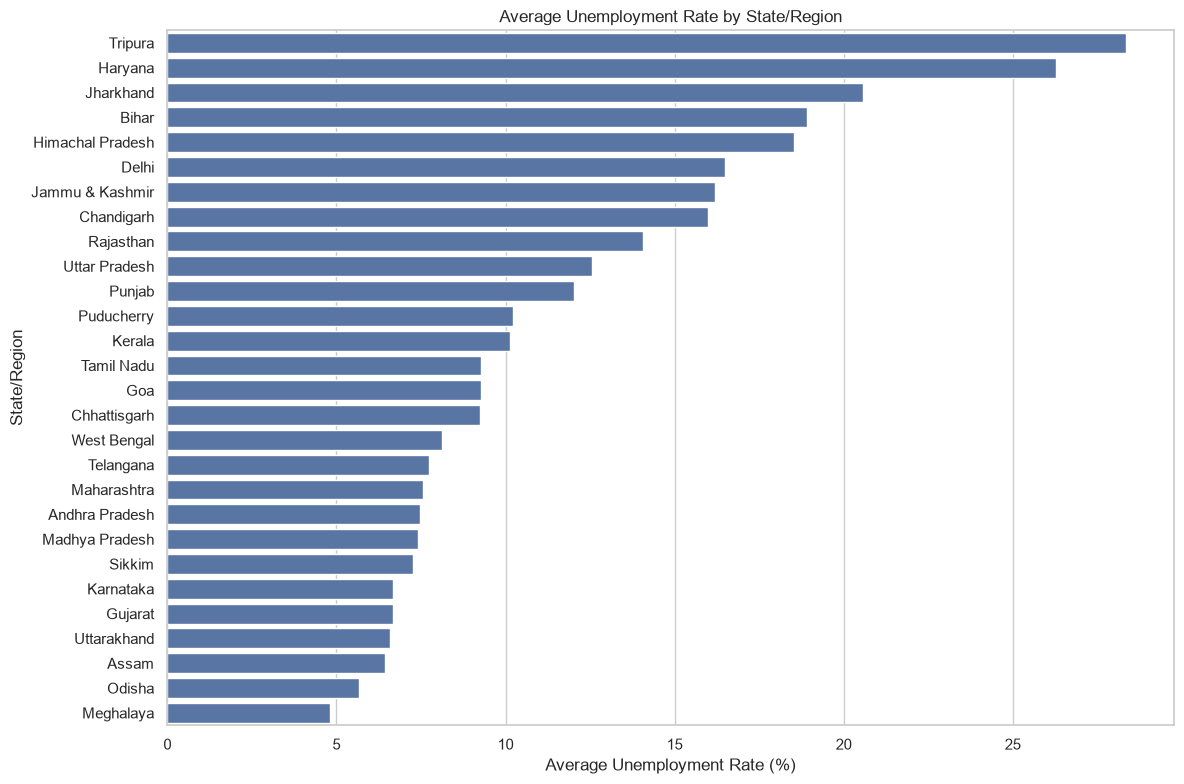

In [7]:

plt.figure(figsize=(12, 8))

sns.barplot(
    x=state_avg.values,
    y=state_avg.index
)

plt.title("Average Unemployment Rate by State/Region")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State/Region")
plt.tight_layout()
plt.show()



### Observation

The chart compares the average unemployment rate across states/regions. States near the top have higher average unemployment rates during the period covered by the dataset, while states near the bottom have lower average rates.


## 6. Month-wise Unemployment Trend

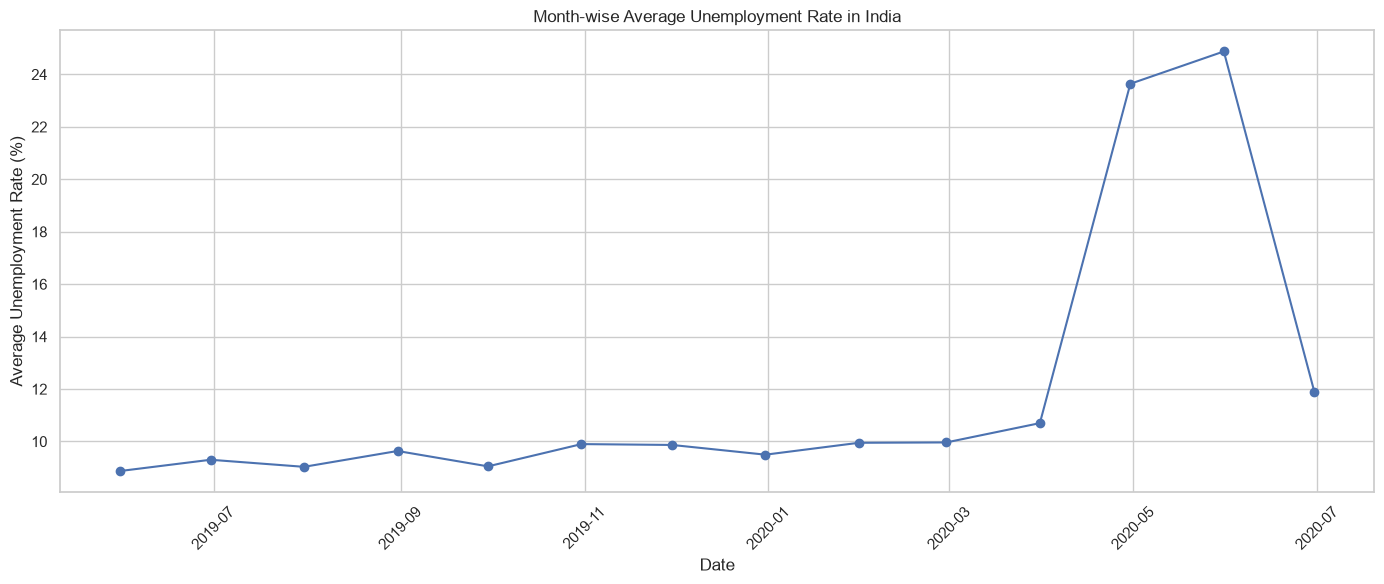

In [8]:

monthly_avg = (
    df.groupby("Date")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_index()
)

plt.figure(figsize=(14, 6))
plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker="o"
)

plt.title("Month-wise Average Unemployment Rate in India")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### Observation

The monthly trend helps identify changes in unemployment over time. A noticeable rise around the beginning of the COVID-19 period indicates the effect of lockdowns and economic disruption on employment.


## 7. Time-Series Comparison of at Least 3 Major States

States selected: ['Maharashtra', 'Tamil Nadu', 'Kerala']


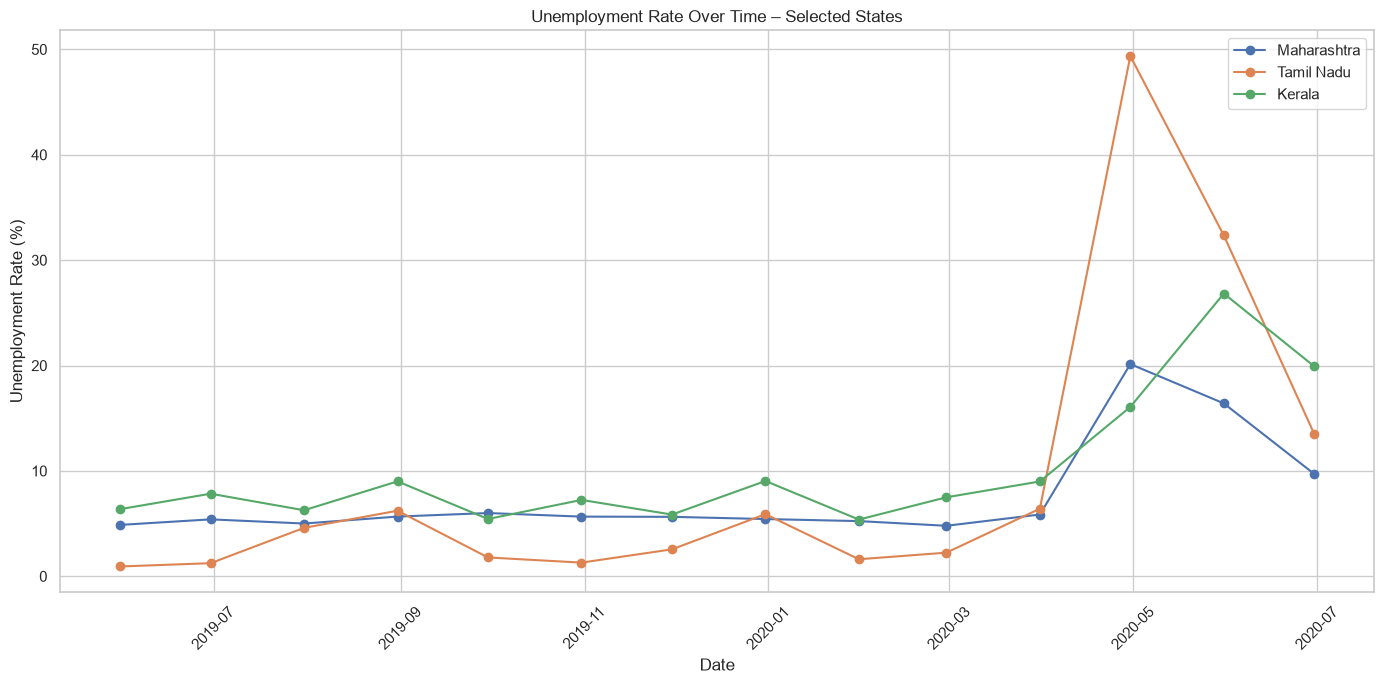

In [9]:

# Automatically select three high-data states if these common states are available.
preferred_states = ["Maharashtra", "Tamil Nadu", "Kerala", "Karnataka", "Delhi"]

available_preferred = [
    state for state in preferred_states
    if state in df["Region"].unique()
]

if len(available_preferred) >= 3:
    selected_states = available_preferred[:3]
else:
    selected_states = (
        df["Region"].value_counts()
          .head(3)
          .index
          .tolist()
    )

print("States selected:", selected_states)

plt.figure(figsize=(14, 7))

for state in selected_states:
    state_data = (
        df[df["Region"] == state]
        .groupby("Date")["Estimated Unemployment Rate (%)"]
        .mean()
        .sort_index()
    )

    plt.plot(
        state_data.index,
        state_data.values,
        marker="o",
        label=state
    )

plt.title("Unemployment Rate Over Time – Selected States")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### Observation

The time-series chart allows comparison of how unemployment changed in three major states. Differences between states can be caused by differences in economic activity, lockdown intensity, industrial structure and labour markets.


## 8. Top 10 States with Highest Average Unemployment

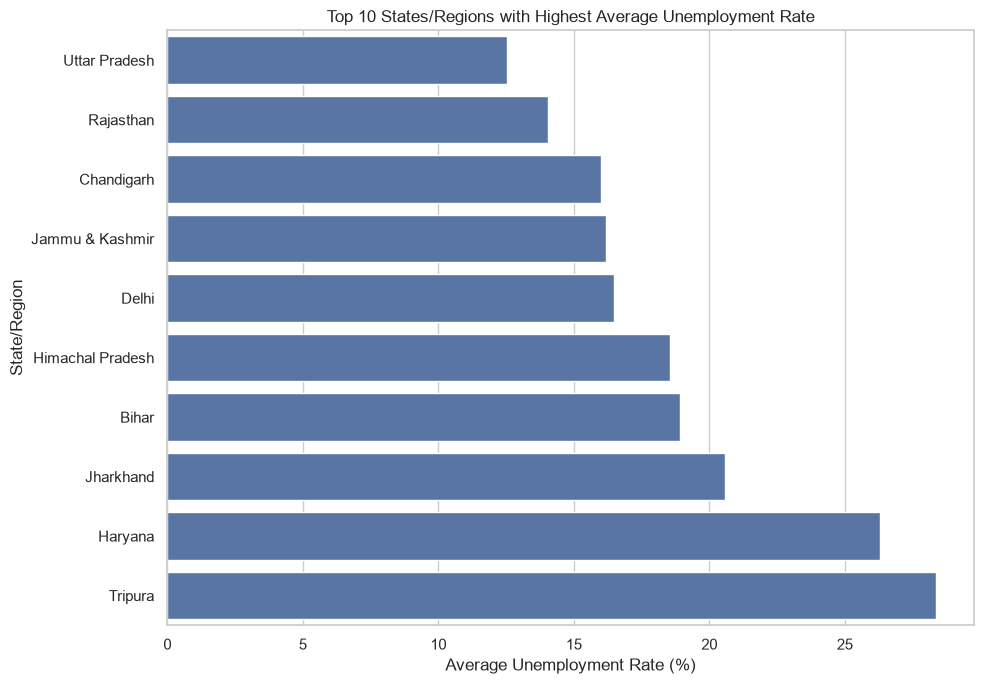

,Average Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


In [10]:

top10 = state_avg.head(10).sort_values()

plt.figure(figsize=(10, 7))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 States/Regions with Highest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State/Region")
plt.tight_layout()
plt.show()

display(top10.to_frame("Average Unemployment Rate (%)").sort_values(
    "Average Unemployment Rate (%)", ascending=False
))



### Observation

This chart highlights the ten states/regions with the highest average unemployment rate in the dataset. It is useful for identifying areas that experienced comparatively greater unemployment during the study period.


## 9. Correlation Heatmap

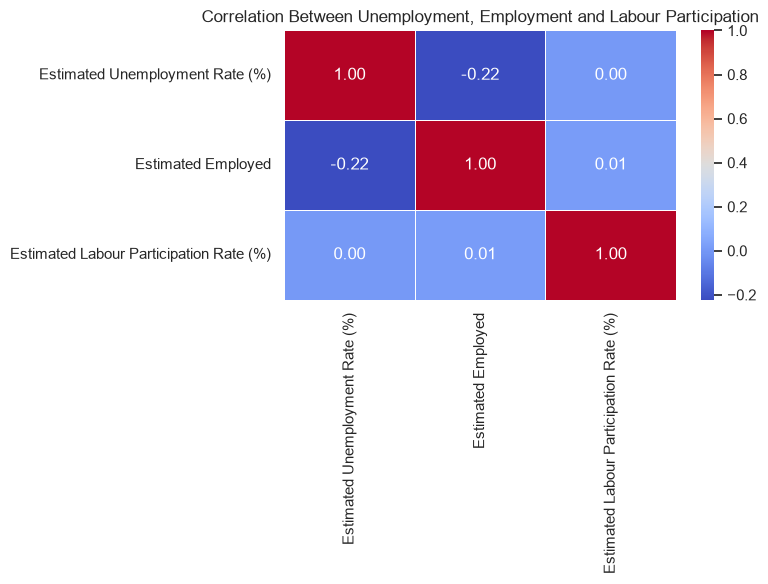

In [11]:

corr_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

correlation = df[corr_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Between Unemployment, Employment and Labour Participation")
plt.tight_layout()
plt.show()



### Observation

The correlation heatmap shows the strength and direction of relationships among unemployment rate, estimated employment and labour participation rate.

**Important:** Correlation indicates association, not causation.


## 10. Pre-COVID vs Post-COVID Comparison

In [12]:

# COVID-19 comparison:
# Pre-COVID  = before 1 March 2020
# Post-COVID = 1 March 2020 onward

covid_cutoff = pd.Timestamp("2020-03-01")

df["Period"] = np.where(
    df["Date"] < covid_cutoff,
    "Pre-COVID",
    "Post-COVID"
)

period_summary = (
    df.groupby("Period")[
        [
            "Estimated Unemployment Rate (%)",
            "Estimated Employed",
            "Estimated Labour Participation Rate (%)"
        ]
    ]
    .mean()
)

display(period_summary)


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Period,,,
Post-COVID,17.774363,6.517203e+06,39.330049
Pre-COVID,9.509534,7.466028e+06,43.886119


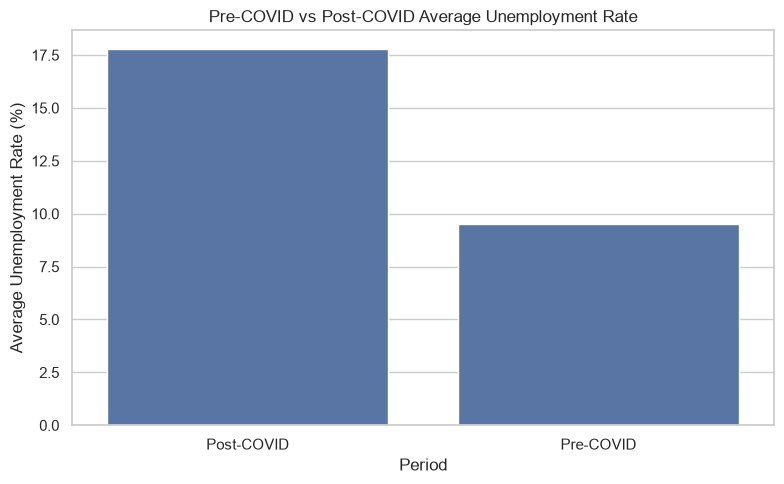

In [13]:

# Visual comparison of average unemployment rate
plt.figure(figsize=(8, 5))

sns.barplot(
    x=period_summary.index,
    y=period_summary["Estimated Unemployment Rate (%)"].values
)

plt.title("Pre-COVID vs Post-COVID Average Unemployment Rate")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")
plt.tight_layout()
plt.show()


In [14]:

# Calculate percentage change in unemployment rate
pre_rate = period_summary.loc[
    "Pre-COVID", "Estimated Unemployment Rate (%)"
]

post_rate = period_summary.loc[
    "Post-COVID", "Estimated Unemployment Rate (%)"
]

percentage_change = ((post_rate - pre_rate) / pre_rate) * 100

print(f"Pre-COVID average unemployment rate: {pre_rate:.2f}%")
print(f"Post-COVID average unemployment rate: {post_rate:.2f}%")
print(f"Percentage change: {percentage_change:.2f}%")


Pre-COVID average unemployment rate: 9.51%
Post-COVID average unemployment rate: 17.77%
Percentage change: 86.91%



### Observation

The pre-COVID and post-COVID averages provide a simple comparison of unemployment before and after the beginning of the pandemic period. If the post-COVID average is higher, the data suggests that unemployment increased during the pandemic period represented in this dataset.


## 11. Optional: Rural vs Urban Analysis

,Average Unemployment Rate (%)
Area,
Urban,13.166614
Rural,10.324791


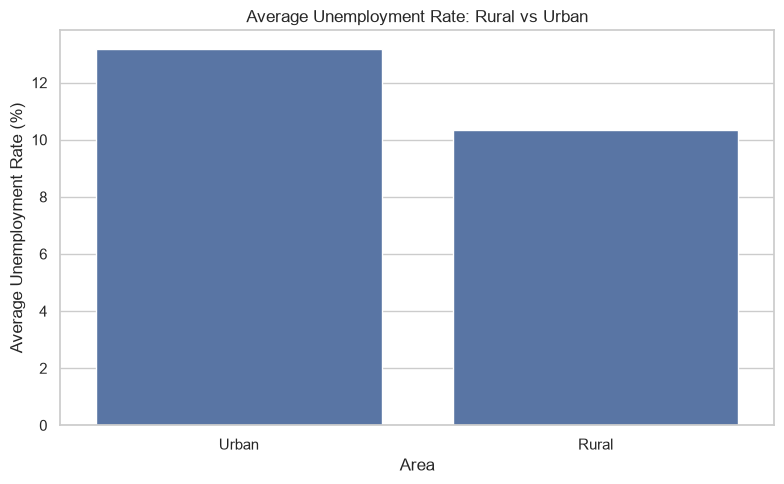

In [15]:

if "Area" in df.columns:
    area_avg = (
        df.groupby("Area")["Estimated Unemployment Rate (%)"]
          .mean()
          .sort_values(ascending=False)
    )

    display(area_avg.to_frame("Average Unemployment Rate (%)"))

    plt.figure(figsize=(8, 5))
    sns.barplot(
        x=area_avg.index,
        y=area_avg.values
    )

    plt.title("Average Unemployment Rate: Rural vs Urban")
    plt.xlabel("Area")
    plt.ylabel("Average Unemployment Rate (%)")
    plt.tight_layout()
    plt.show()
else:
    print("Area column is not available in this version of the dataset.")



## 12. Final Conclusions

### Key findings to report

1. The dataset provides unemployment, employment and labour-participation information for Indian states/regions over time.
2. State-wise averages show significant differences in unemployment rates across regions.
3. Monthly time-series analysis helps identify changes in unemployment over the study period.
4. The COVID-19 period can be compared with the pre-COVID period using the date column.
5. The pre-COVID vs post-COVID comparison helps quantify the change in average unemployment.
6. The correlation heatmap shows how unemployment is associated with estimated employment and labour-force participation.
7. Petty differences between states should be interpreted in the context of the dataset's coverage, time period and measurement method.

### Overall conclusion

The analysis shows that unemployment in India varied considerably across regions and over time. The COVID-19 period is associated with a substantial disruption in employment conditions in the dataset, making the pandemic period an important point for comparison. Data visualization and statistical summaries provide a clear way to understand these regional and temporal patterns.
